# Pothole Dataset Exploration

This notebook explores the PothRGDB dataset and the Rui Fan datasets using the manifest generated by `project/code/scripts/inspect_datasets.py`.

Goals:
- verify sample pairings
- inspect image, depth, and label formats
- visualize a few examples before conversion to 3D point clouds

In [1]:
from pathlib import Path

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['image.cmap'] = 'gray'

In [2]:
code_root = Path('..').resolve()
artifacts_dir = code_root / 'artifacts'
manifest_path = artifacts_dir / 'pothrgbd_manifest.csv'
summary_path = artifacts_dir / 'pothrgbd_summary.json'
rui_summary_path = artifacts_dir / 'rui_fan_summary.json'

manifest = pd.read_csv(manifest_path)
summary = json.loads(summary_path.read_text())
rui_summary = json.loads(rui_summary_path.read_text())

print('PothRGDB samples:', len(manifest))
print('PothRGDB issues:', summary['samples_with_issues'])
print('Rui Fan subsets:', [subset['name'] for subset in rui_summary['subsets']])

PothRGDB samples: 998
PothRGDB issues: 2
Rui Fan subsets: ['rethinking_road_reconstruction_pothole_detection-main', 'road_surface_3d_reconstruction_datasets-master', 'stereo_pothole_datasets-master']


In [3]:
manifest.head()

,dataset,sample_id,image_path,depth_path,label_path,status,notes
0,PothRGDB,20250227_135438,images/20250227_135438_color_png.rf.984e9768eb...,depths/20250227_135438_depth.npy,labels/20250227_135438_color_png.rf.984e9768eb...,ok,NaN
1,PothRGDB,20250227_135652,images/20250227_135652_color_png.rf.c3e37f97ea...,depths/20250227_135652_depth.npy,labels/20250227_135652_color_png.rf.c3e37f97ea...,ok,NaN
2,PothRGDB,20250227_140407,images/20250227_140407_color_png.rf.c447527046...,depths/20250227_140407_depth.npy,labels/20250227_140407_color_png.rf.c447527046...,ok,NaN
3,PothRGDB,20250227_140905,images/20250227_140905_color_png.rf.2d12799a85...,depths/20250227_140905_depth.npy,labels/20250227_140905_color_png.rf.2d12799a85...,ok,NaN
4,PothRGDB,20250227_141050,images/20250227_141050_color_png.rf.4682f3a780...,depths/20250227_141050_depth.npy,labels/20250227_141050_color_png.rf.4682f3a780...,ok,NaN


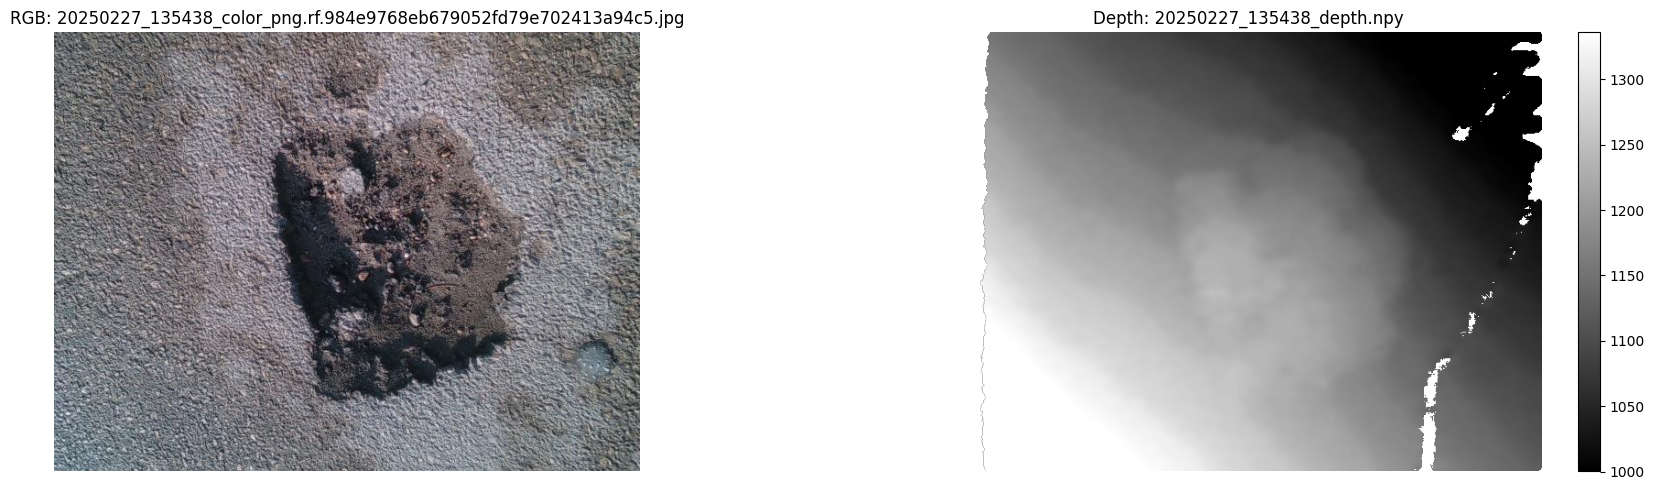

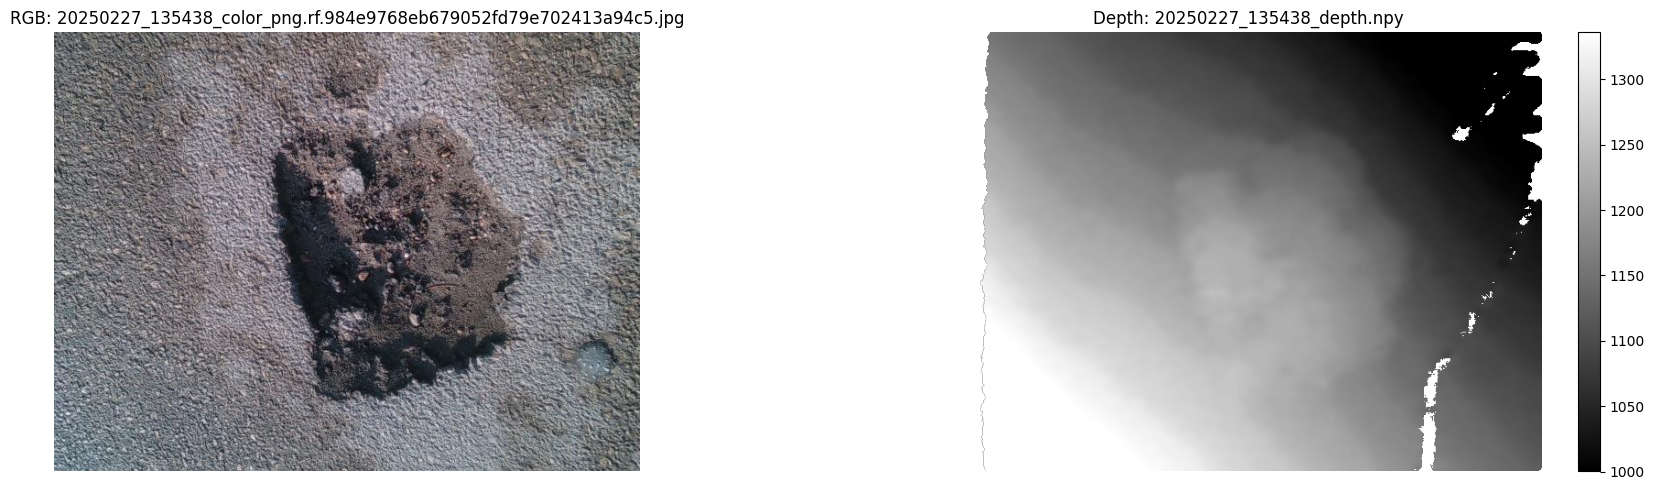

In [7]:
def show_pothrgbd_sample(row_index: int = 0):
    row = manifest.iloc[row_index]
    dataset_root = code_root / 'datasets' / 'PothRGDB' / 'PUBLIC POTHOLE DATASET'
    image_path = dataset_root / row['image_path']
    depth_path = dataset_root / row['depth_path']
    label_path = dataset_root / row['label_path']

    image = Image.open(image_path).convert('RGB')
    depth = np.load(depth_path)

    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    axes[0].imshow(image)
    axes[0].set_title(f'RGB: {image_path.name}')
    axes[0].axis('off')

    depth_vis = np.where(depth == 0, np.nan, depth)
    im = axes[1].imshow(depth_vis, vmin=np.nanpercentile(depth_vis, 5), vmax=np.nanpercentile(depth_vis, 95))
    axes[1].set_title(f'Depth: {depth_path.name}')
    axes[1].axis('off')
    fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

    # axes[2].text(0.02, 0.95, label_path.read_text()[:800], va='top', family='monospace')
    # axes[2].set_title(f'YOLO label: {label_path.name}')
    # axes[2].axis('off')

    fig.tight_layout()
    return fig

show_pothrgbd_sample(0)

In [5]:
def print_rui_fan_overview():
    for subset in rui_summary['subsets']:
        print(f"=== {subset['name']} ===")
        if subset['file_counts']:
            print('Top-level files:', subset['file_counts'])
        for subdir in subset['subdirs']:
            print(f"  - {subdir['name']}: {subdir['file_total']} files -> {subdir['file_counts']}")

print_rui_fan_overview()

=== rethinking_road_reconstruction_pothole_detection-main ===
Top-level files: {'[no_ext]': 1, '.md': 1}
  - dataset: 70 files -> {'.mat': 3, '.ply': 13, '.png': 54}
  - figs: 5 files -> {'.gif': 1, '.jpg': 1, '.png': 3}
  - materials: 19 files -> {'.jpg': 12, '.pdf': 2, '.png': 1, '.rar': 1, '.txt': 1, '.zip': 2}
=== road_surface_3d_reconstruction_datasets-master ===
Top-level files: {'[no_ext]': 1, '.md': 1}
  - dataset 1: 177 files -> {'.m': 1, '.mat': 36, '.png': 140}
  - dataset 2: 180 files -> {'.m': 1, '.mat': 36, '.png': 143}
  - dataset 3: 85 files -> {'.mat': 1, '.png': 84}
  - figs: 1 files -> {'.gif': 1}
=== stereo_pothole_datasets-master ===
Top-level files: {'[no_ext]': 1, '.md': 1, '.m': 1}
  - dataset1: 132 files -> {'.mat': 44, '.png': 88}
  - dataset2: 240 files -> {'.mat': 80, '.png': 160}
  - dataset3: 30 files -> {'.mat': 10, '.png': 20}


In [6]:
# Suggested next step: load a Rui Fan point cloud sample with scipy.io.loadmat or open3d
# and compare its structure with a PothRGDB-derived point cloud after conversion.